Week -2 (Numeric and Image)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
import os, zipfile, random
from PIL import Image


In [ ]:
dfN = pd.read_csv("loan_approval_numeric.csv")
print("Shape (rows, cols):", dfN.shape)
display(dfN.head())

Shape (rows, cols): (250, 13)


,age,gender,annual_income,credit_score,employment_years,loan_amount,loan_term_months,interest_rate,num_credit_lines,debt_to_income,late_payments_12m,existing_loans,loan_accepted
0,56,1,102896,503.0,26.0,34187,48,17.88,5,0.10,5,1,1
1,46,1,101879,517.0,33.0,52356,36,4.69,5,0.59,0,2,0
2,32,1,89295,773.0,37.0,11789,48,14.18,5,0.17,4,0,1
3,60,1,106614,731.0,32.0,33184,60,6.03,1,0.24,2,4,1
4,25,1,118689,640.0,23.0,2120,36,17.11,1,0.19,1,3,0


In [ ]:
missing = dfN.isna().sum()
print("Missing values per column:")
display(missing[missing > 0] if (missing > 0).any() else "No missing values found.")

Missing values per column:


,0
credit_score,5
employment_years,5
debt_to_income,5


,count
loan_accepted,
0,172
1,78


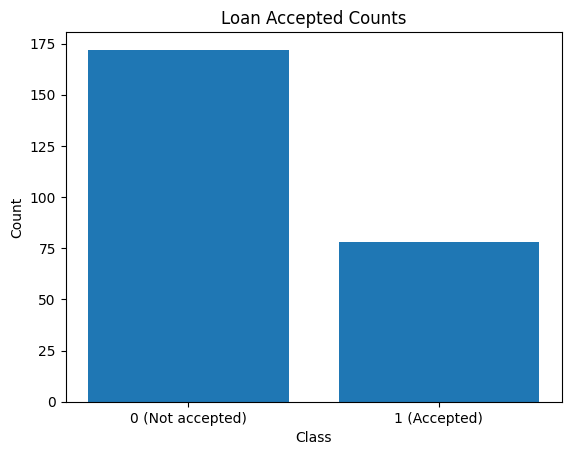

In [ ]:
target_col = "loan_accepted" # change if your column name is different
counts = dfN[target_col].value_counts().sort_index()
display(counts)
plt.bar(["0 (Not accepted)", "1 (Accepted)"], counts.values)
plt.title("Loan Accepted Counts")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


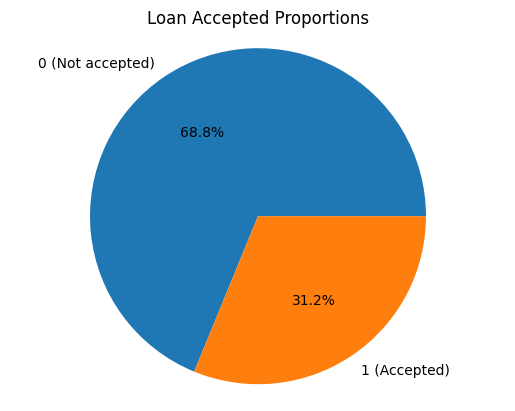

In [ ]:
plt.pie(counts.values, labels=["0 (Not accepted)", "1 (Accepted)"],
autopct="%1.1f%%")
plt.title("Loan Accepted Proportions")
plt.axis("equal")
plt.show()


In [ ]:
cols_to_compare = ["annual_income", "credit_score", "debt_to_income",
"loan_amount", "late_payments_12m"]
cols_to_compare = [c for c in cols_to_compare if c in dfN.columns]
group_means = dfN.groupby(target_col)[cols_to_compare].mean(numeric_only=True)
display(group_means)

,annual_income,credit_score,debt_to_income,loan_amount,late_payments_12m
loan_accepted,,,,,
0,63323.831395,532.791667,0.385740,33340.959302,2.866279
1,78518.230769,654.597403,0.238421,24469.589744,2.410256


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
import os, zipfile, random
from PIL import Image


In [ ]:
dfT = pd.read_csv("patient_notes_risk.csv")
print("Shape:", dfT.shape)
display(dfT.head())

Shape: (30, 2)


,patient_note,risk_label
0,Patient reports increased thirst and frequent ...,1
1,"Regular exercise, balanced meals, and no curre...",0
2,Feeling tired after meals and experiencing blu...,1
3,No concerns today. Sleep is good and energy le...,0
4,"Reports dry mouth, constant hunger, and waking...",1


In [ ]:
def clean_text(s):
 s = str(s).lower()
 s = re.sub(r"[^a-z\s]", "", s)
 s = re.sub(r"\s+", " ", s).strip()
 return s
dfT["clean_note"] = dfT["patient_note"].apply(clean_text)
all_words = " ".join(dfT["clean_note"]).split()
word_counts = Counter(all_words)
top_words = pd.DataFrame(word_counts.most_common(10), columns=["word", "count"])
display(top_words)

,word,count
0,and,29
1,reports,15
2,patient,11
3,no,10
4,regular,6
5,good,6
6,feels,6
7,increased,5
8,meals,5
9,sleep,5


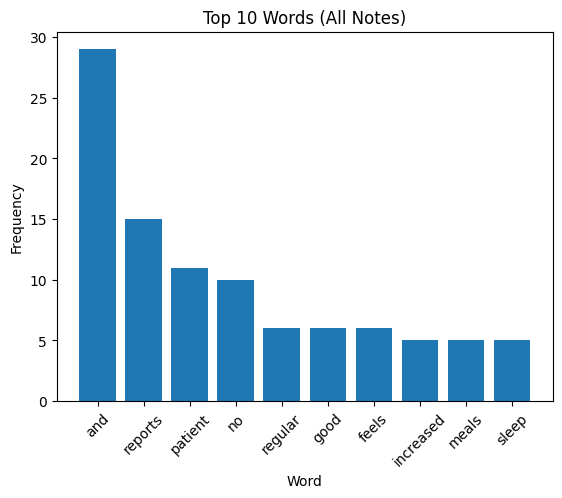

In [ ]:
plt.bar(top_words["word"], top_words["count"])
plt.title("Top 10 Words (All Notes)")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [ ]:
label_col = "risk_label" # change if your column name is different
risk_words = " ".join(dfT[dfT[label_col] == 1]["clean_note"]).split()
nonrisk_words = " ".join(dfT[dfT[label_col] == 0]["clean_note"]).split()
risk_top = pd.DataFrame(Counter(risk_words).most_common(10), columns=["word",
"count"])
nonrisk_top = pd.DataFrame(Counter(nonrisk_words).most_common(10),
columns=["word", "count"])
print("Top words (Risk = 1)")
display(risk_top)
print("Top words (Non-risk = 0)")
display(nonrisk_top)


Top words (Risk = 1)


,word,count
0,and,15
1,reports,8
2,patient,5
3,increased,5
4,thirst,4
5,frequent,4
6,urination,4
7,blurred,4
8,vision,4
9,tiredness,4


Top words (Non-risk = 0)


,word,count
0,and,14
1,no,10
2,reports,7
3,regular,6
4,good,6
5,patient,6
6,symptoms,4
7,sleep,4
8,normal,4
9,exercise,3


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
import os, zipfile, random
from PIL import Image

In [ ]:
zip_path = "week2_images_4class.zip"
extract_root = "week2_images_4class_extracted"
with zipfile.ZipFile(zip_path, "r") as z:
 z.extractall(extract_root)
print("Extracted to:", extract_root)
print("Top-level folders:", os.listdir(extract_root))

Extracted to: week2_images_4class_extracted
Top-level folders: ['week2_images_4class']


In [ ]:
# Find folder that contains train/ and test/
base = extract_root
# if there's a single folder inside, go into it
items = os.listdir(base)
if len(items) == 1 and os.path.isdir(os.path.join(base, items[0])):
 candidate = os.path.join(base, items[0])
 if os.path.exists(os.path.join(candidate, "train")): base = candidate
train_dir = os.path.join(base, "train")
test_dir = os.path.join(base, "test")
print("Using base folder:", base)
print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))
classes = sorted(os.listdir(train_dir))
print("Classes:", classes)


Using base folder: week2_images_4class_extracted/week2_images_4class
Train exists: True
Test exists: True
Classes: ['airplane', 'cat', 'dog', 'truck']


In [ ]:
rows = []
for c in classes:
 train_count = len(os.listdir(os.path.join(train_dir, c)))
 test_count = len(os.listdir(os.path.join(test_dir, c)))
 rows.append([c, train_count, test_count])
counts_df = pd.DataFrame(rows, columns=["class", "train_images", "test_images"])
display(counts_df)

,class,train_images,test_images
0,airplane,250,50
1,cat,250,50
2,dog,250,50
3,truck,250,50


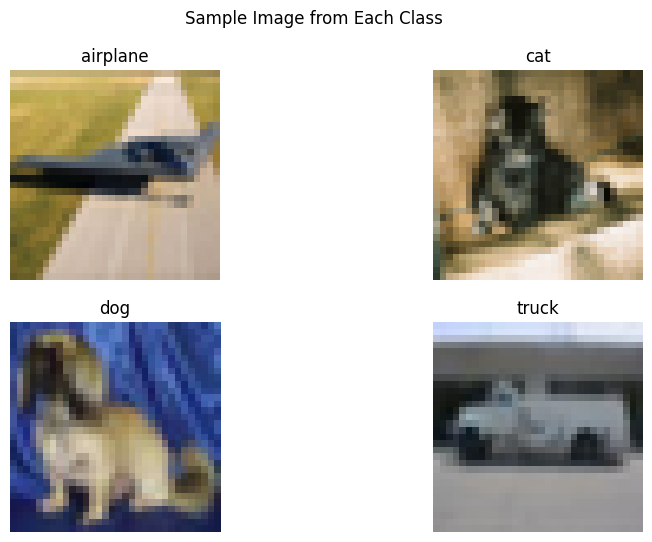

In [ ]:
plt.figure(figsize=(10,6))
for i, c in enumerate(classes):
 file_list = os.listdir(os.path.join(train_dir, c))
 pick = random.choice(file_list)
 img_path = os.path.join(train_dir, c, pick)
 img = Image.open(img_path)
 plt.subplot(2, 2, i+1) # works well for 4 classes
 plt.imshow(img)
 plt.title(c)
 plt.axis("off")
plt.suptitle("Sample Image from Each Class")
plt.show()

In [ ]:
sample_class = classes[0]
sample_file = os.listdir(os.path.join(train_dir, sample_class))[0]
sample_path = os.path.join(train_dir, sample_class, sample_file)
img = Image.open(sample_path)
arr = np.array(img)
print("Sample class:", sample_class)
print("Image shape (H, W, C):", arr.shape)
print("Pixel range:", arr.min(), "to", arr.max())

Sample class: airplane
Image shape (H, W, C): (32, 32, 3)
Pixel range: 0 to 255


,class,avg_brightness
0,airplane,0.574752
1,cat,0.476595
2,dog,0.480196
3,truck,0.491008


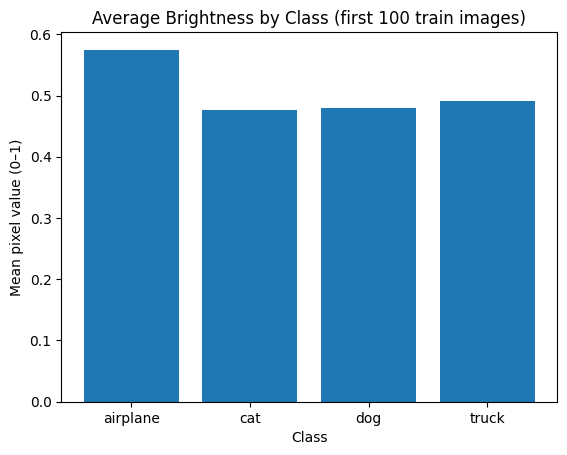

In [ ]:
def mean_brightness(path):
 a = np.array(Image.open(path)).astype("float32") / 255.0
 return a.mean()
brightness = {}
for c in classes:
 files = os.listdir(os.path.join(train_dir, c))[:100] # first 100 for speed
 paths = [os.path.join(train_dir, c, f) for f in files]
 brightness[c] = float(np.mean([mean_brightness(p) for p in paths]))
brightness_df = pd.DataFrame(list(brightness.items()), columns=["class",
"avg_brightness"])
display(brightness_df)
plt.bar(brightness_df["class"], brightness_df["avg_brightness"])
plt.title("Average Brightness by Class (first 100 train images)")
plt.xlabel("Class")
plt.ylabel("Mean pixel value (0–1)")
plt.show()